<a href="https://colab.research.google.com/github/DebStar17/Make-Moons/blob/main/Neural_Network_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Network

In [ ]:
import random
import numpy as np

# ACTIVATION FUNCTIONS
def sigmoid(z):
    # Caps the values between -250 and 250
    z = np.clip(z, -250, 250)
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_prime(z):
    """Derivative of the sigmoid function."""
    return sigmoid(z)*(1-sigmoid(z))

def relu(z):
    return np.maximum(0, z)

def relu_prime(z):
    return np.where(z > 0, 1, 0)

# Actual Network Code
class Layer():
    def __init__(self, out_size, inp_size, activation, activation_prime):
        self.size = out_size
        self.bias = np.random.randn(out_size, 1)
        self.weight_mat = np.random.randn(out_size, inp_size) * np.sqrt(2.0 / inp_size)
        self.activation = activation
        self.activation_prime = activation_prime

    def give_input(self, input):
        self.input = input
        self.z = np.dot(self.weight_mat, self.input) + self.bias
        self.output = self.activation(self.z)
        return self.output

class Network():

    def __init__(self, sizes):
        self.num_layers = len(sizes)
        self.sizes = sizes
        self.layers = [] # this includes output layer

        # CHANGE THE ACTIVATION FUNCTION HERE
        for i in range(1, len(sizes)):
            if i == len(sizes) - 1:
                f = sigmoid
                f_prime = sigmoid_prime
            else:
                f = relu
                f_prime = relu_prime
            self.layers.append(Layer(sizes[i], sizes[i-1], f, f_prime))

    def feedforward(self, a):
        assert type(a) == np.ndarray, "Input must be a numpy array"

        for layer in self.layers:
            a = layer.give_input(a)
        return a

    def backprop(self, y, alpha):
        assert type(y) == np.ndarray, "Input must be a numpy array"
        m = y.shape[1]

        # --- Output Layer ---
        layer = self.layers[-1]
        delta = (layer.output - y) * layer.activation_prime(layer.z)

        # Divide by m to average the gradient across the batch
        layer.weight_mat -= alpha * (1/m) * np.dot(delta, layer.input.T)
        layer.bias -= alpha * (1/m) * np.sum(delta, axis=1, keepdims=True)

        # --- Hidden Layers ---
        for i in range(1, len(self.layers)):
            layer = self.layers[-1 - i]
            prev_layer = self.layers[-i]

            delta = np.dot(prev_layer.weight_mat.T, delta) * layer.activation_prime(layer.z)
            layer.weight_mat -= alpha * (1/m) * np.dot(delta, layer.input.T)
            layer.bias -= alpha * (1/m) * np.sum(delta, axis=1, keepdims=True)

    def train(self, X, y, epochs, alpha, batch_size=32):
        self.losses = []
        assert type(X) == np.ndarray, "Input must be a numpy array"
        assert type(y) == np.ndarray, "Output must be a numpy array"
        num_samples = X.shape[0]  # Row count = total samples (800)

        for epoch in range(epochs):
            # 1. Shuffle row indices
            permutation = np.random.permutation(num_samples)
            X_shuffled = X[permutation]
            y_shuffled = y[permutation]

            # 2. Loop through in steps of batch_size
            for i in range(0, num_samples, batch_size):
                X_batch = X_shuffled[i : i + batch_size].T
                y_batch = y_shuffled[i : i + batch_size].reshape(1, -1)

                # 4. Pass the batch through
                output = self.feedforward(X_batch)
                self.backprop(y_batch, alpha)

            full_output = self.feedforward(X.T)
            y_full_reshaped = y.reshape(1, -1)

            # Compute total MSE Loss for the entire dataset
            epoch_loss = (1.0 / (2.0 * num_samples)) * np.sum((y_full_reshaped - full_output) ** 2)
            self.losses.append(epoch_loss)

#### Data

In [ ]:
from sklearn.datasets import make_moons
# Generate 1000 samples with a bit of noise
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
# X shape: (1000, 2) -> 2D features
# y shape: (1000,) -> Binary labels (0 or 1)

from sklearn.model_selection import train_test_split
# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# X_train shape: (800, 2), y_train shape: (800,)
# X_test shape: (200, 2), y_test shape: (200,)

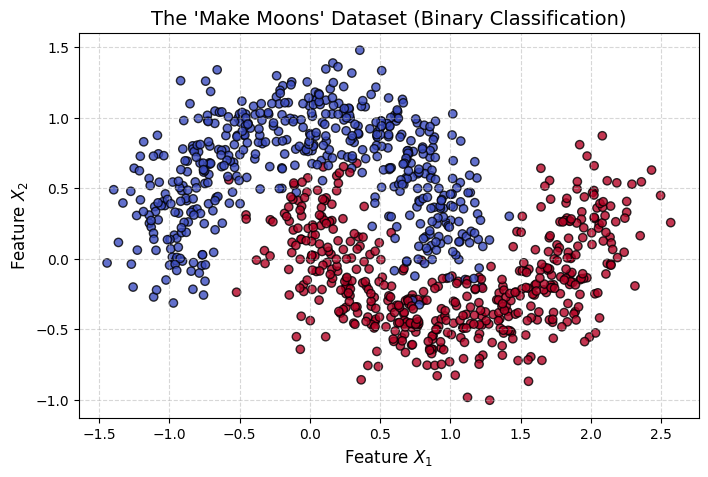

In [ ]:
import matplotlib.pyplot as plt

# 2. Create the scatter plot
plt.figure(figsize=(8, 5))

# X[:, 0] is the x-coordinate, X[:, 1] is the y-coordinate
# c=y automatically colors the points based on their class label (0 or 1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', alpha=0.8)

# Adding labels and styling
plt.title("The 'Make Moons' Dataset (Binary Classification)", fontsize=14)
plt.xlabel("Feature $X_1$", fontsize=12)
plt.ylabel("Feature $X_2$", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def plot_decision_boundary(net, X, y):
    # 1. Define the limits of the plot based on your dataset bounds
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # 2. Create a dense grid of points (spacing of 0.01)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

    # 3. Flatten the grid arrays and stack them into a (2, N) matrix
    # This matches the shape your network's feedforward expects!
    grid_points = np.vstack([xx.ravel(), yy.ravel()])

    # 4. Get the network's predictions for the entire grid
    # Output shape will be (1, N)
    probs = net.feedforward(grid_points)

    # 5. Reshape the flat probabilities back into the 2D grid shape
    probs = probs.reshape(xx.shape)

    # 6. Plot the background color contours
    plt.figure(figsize=(10, 6))
    # contourf draws filled contours. levels=100 makes the color gradient smooth.
    plt.contourf(xx, yy, probs, levels=100, cmap="coolwarm", alpha=0.7)

    # 7. Draw a sharp line where the probability is exactly 0.5 (The Decision Boundary)
    plt.contour(
        xx,
        yy,
        probs,
        levels=[0.05, 0.95],
        colors="black",
        linestyles="--",
        linewidths=2,
    )

    # 8. Scatter plot the actual training data points on top
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=40)

    plt.title("Neural Network Decision Boundary", fontsize=14)
    plt.xlabel("Feature $X_1$")
    plt.ylabel("Feature $X_2$")
    plt.colorbar(label="Network Probability Output (Sigmoid)")
    plt.show()

#### Start

In [ ]:
net = Network([2,64,64,1])
epochs=700
alpha=0.01
batch_size=32
net.train(X_train, y_train, epochs, alpha, batch_size)


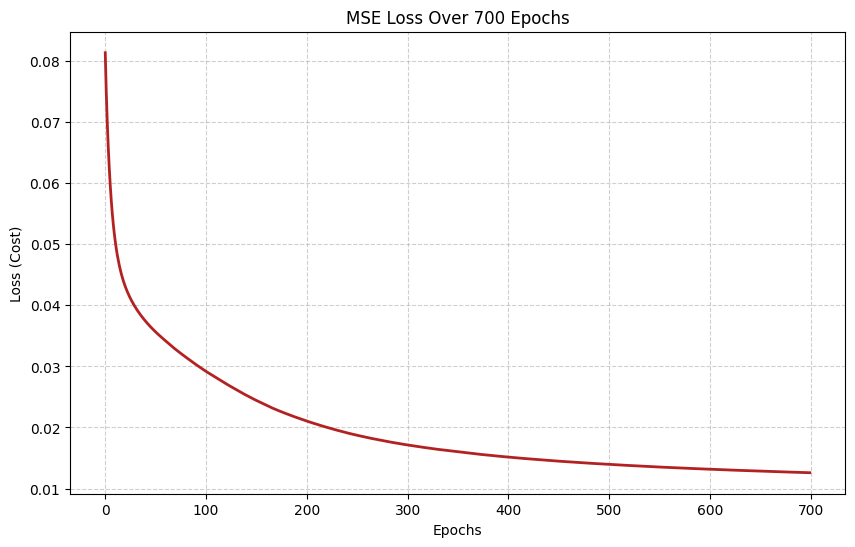

In [ ]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(net.losses, color='firebrick', linewidth=2)
plt.title(f"MSE Loss Over {epochs} Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss (Cost)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Test Accuracy: 98.00%


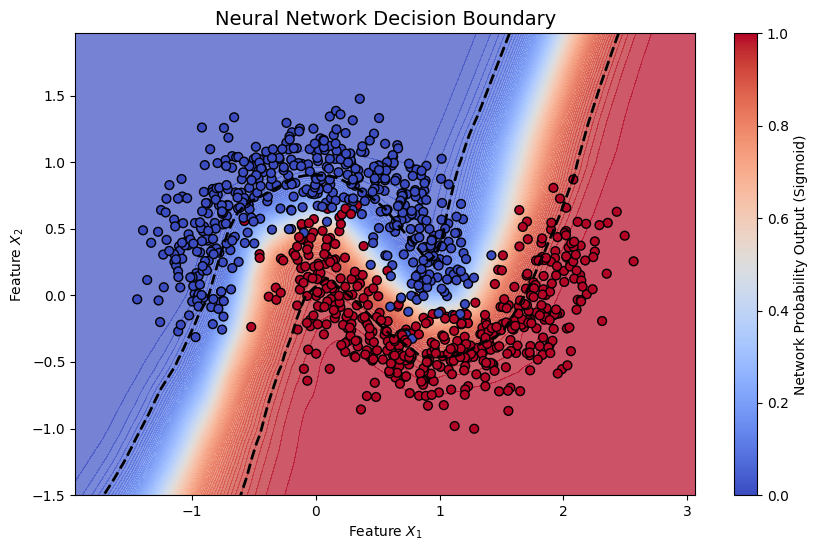

In [ ]:
from sklearn.metrics import accuracy_score

probs = net.feedforward(X_test.T)  # remember to pass test data transposed
preds = (probs >= 0.5).astype(int).ravel()
print(f"Test Accuracy: {accuracy_score(y_test, preds)*100:.2f}%")

# 4. Plot it!
plot_decision_boundary(net, X, y)